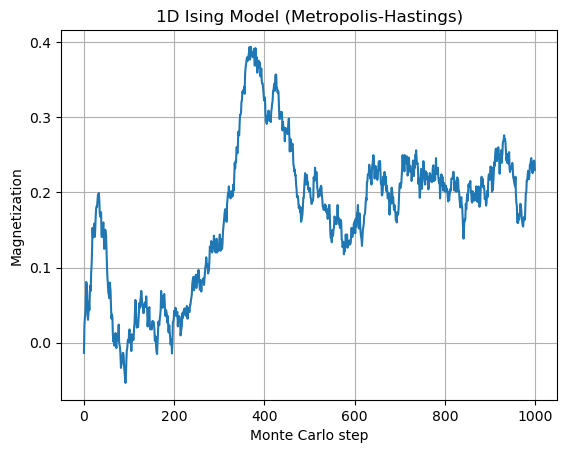

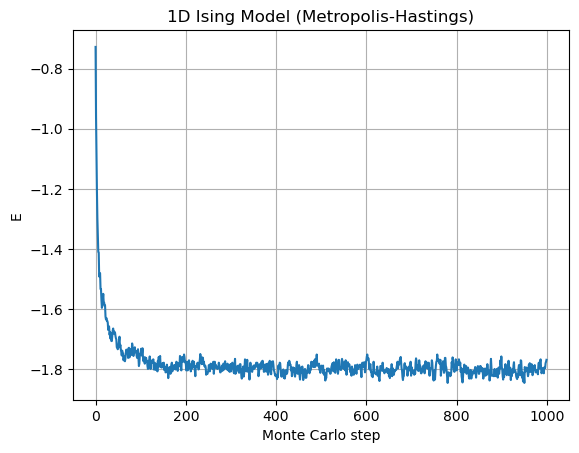

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

# Parameters
L = 50               # Lattice size (LxL)
J = 1.0              # Interaction strength
T = 1.6              # Temperature
n_steps = 1000       # Number of Monte Carlo steps

# Initialize lattice with spins (+1 or -1)
def initialize_lattice(L):
    return np.random.choice([-1, 1], size=(L, L))

# Calculate energy change for flipping spin at (i, j)
def delta_energy(L, J, lattice, i, j):
    spin = lattice[i, j]
    neighbors = lattice[(i+1)%L, j] + lattice[(i-1)%L, j] + \
                lattice[i, (j+1)%L] + lattice[i, (j-1)%L]
    return 2 * J * spin * neighbors

# Total energy of the system
def total_energy(L, J, lattice):
    E = 0
    for i in range(L):
        for j in range(L):
            spin = lattice[i, j]
            neighbors = lattice[(i+1)%L, j] + lattice[i, (j+1)%L]
            E -= J*spin * neighbors
    return E

# Perform Metropolis step
def metropolis_step(L, J, lattice, T):
    for _ in range(L * L):
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        dE = delta_energy(L, J, lattice, i, j)
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            lattice[i, j] *= -1

# Compute magnetization
def magnetization(L, lattice):
    return np.sum(lattice) / (L * L)

def simulate_ising_2d(L, J, T, n_steps):
    """Run the 2D Ising model simulation."""
    beta = 1.0 / T
    lattice = initialize_lattice(L)
    magnetizations = []
    energies = []
    
    for step in range(n_steps):
        metropolis_step(L, J, lattice, T)
        mag = magnetization(L, lattice)
        magnetizations.append(mag)
        en = total_energy(L, J, lattice) / (L * L)
        energies.append(en)
            
    return lattice, magnetizations, energies

final_spins, mags, Es = simulate_ising_2d(L, J, T, n_steps)

# Plot magnetization over time
plt.plot(mags)
plt.xlabel('Monte Carlo step')
plt.ylabel('Magnetization')
plt.title('1D Ising Model (Metropolis-Hastings)')
plt.grid(True)
plt.show()

# Plot Energy over time
plt.plot(Es)
plt.xlabel('Monte Carlo step')
plt.ylabel('E')
plt.title('1D Ising Model (Metropolis-Hastings)')
plt.grid(True)
plt.show()

Text(0.5, 1.0, '2D Ising Model')

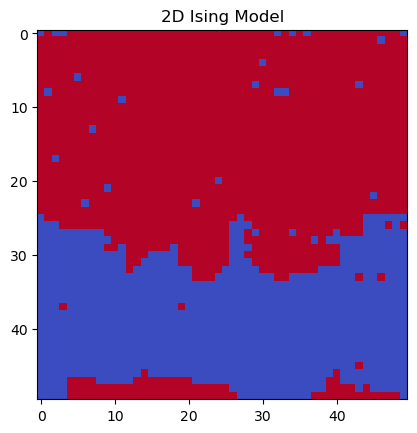

In [5]:
fig, ax = plt.subplots()
im = ax.imshow(final_spins, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title("2D Ising Model")